<a href="https://www.kaggle.com/code/lalit7881/indian-tech-job-market-26-eda?scriptVersionId=330685173" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shree0910/india-tech-job-market-2026-23k-records/indian_tech_jobs_2026.csv


## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/shree0910/india-tech-job-market-2026-23k-records/indian_tech_jobs_2026.csv")

In [3]:
df.head()

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,2025-06-10,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21.0,False,False
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21.0,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,...,2025-06-10,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21.0,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21.0,False,False


In [4]:
df.tail()

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
23196,23197,Python Developer-Hyderabad,Infosys,3.5,Hybrid - Hyderabad,Hyderabad,Python Developer,2-7 Yrs,2.0,7.0,...,2025-06-10,Undisclosed,Junior (0-2 Yrs),False,Hyderabad,Data Science,0.0,1.0,False,False
23197,23198,Python Developer,Accufy,3.6,Hyderabad,Hyderabad,Python Developer,0-4 Yrs,0.0,4.0,...,2025-06-10,Undisclosed,Fresher,False,Hyderabad,Data Science,0.0,1.0,True,False
23198,23199,Walk in Interview Python Developer II Hyderabad,Tata Consultancy Services,3.3,"Hyderabad, Pune, Mumbai (All Areas)",Hyderabad,Python Developer,13 Jun,13.0,8.0,...,2025-06-10,Undisclosed,Lead/Architect (9+ Yrs),False,Hyderabad,Data Engineering,0.0,21.0,False,False
23199,23200,Python Developer,Mediamint,2.8,Hybrid - Hyderabad,Hyderabad,Python Developer,3-5 Yrs,3.0,5.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Data Science,0.0,0.0,False,False
23200,23201,Python Developer,CMM Level 5 IT Company,3.6,Hyderabad,Hyderabad,Python Developer,7-12 Yrs,7.0,12.0,...,2025-06-10,Senior (10-20 LPA),Senior (6-8 Yrs),False,Hyderabad,Data Science,13.0,1.0,False,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23201 entries, 0 to 23200
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               23201 non-null  int64  
 1   job_title            23201 non-null  object 
 2   company_name         23201 non-null  object 
 3   company_rating       23201 non-null  float64
 4   location             23201 non-null  object 
 5   scraped_city         23201 non-null  object 
 6   role_category        23201 non-null  object 
 7   experience_raw       23201 non-null  object 
 8   experience_min_yrs   23201 non-null  float64
 9   experience_max_yrs   23201 non-null  float64
 10  salary_raw           23201 non-null  object 
 11  salary_min_lpa       23201 non-null  float64
 12  salary_max_lpa       23201 non-null  float64
 13  salary_disclosed     23201 non-null  bool   
 14  skills_required      23201 non-null  object 
 15  skills_count         23201 non-null 

In [6]:
df.describe()

,job_id,company_rating,experience_min_yrs,experience_max_yrs,salary_min_lpa,salary_max_lpa,skills_count,salary_midpoint_lpa,days_since_posted
count,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000
mean,11601.000000,3.586449,4.135080,7.829059,1.383952,2.271790,7.604198,1.827872,15.698935
std,6697.696134,0.514250,2.933976,3.946834,4.841570,7.469383,1.456530,6.109373,7.575881
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5801.000000,3.400000,2.000000,5.000000,0.000000,0.000000,8.000000,0.000000,7.000000
50%,11601.000000,3.600000,4.000000,8.000000,0.000000,0.000000,8.000000,0.000000,21.000000
75%,17401.000000,3.800000,6.000000,10.000000,0.000000,0.000000,8.000000,0.000000,21.000000
max,23201.000000,5.000000,25.000000,31.000000,85.000000,90.000000,8.000000,87.500000,90.000000


In [7]:
df.isnull()

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23196,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
23197,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
23198,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
23199,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

job_id                  0
job_title               0
company_name            0
company_rating          0
location                0
scraped_city            0
role_category           0
experience_raw          0
experience_min_yrs      0
experience_max_yrs      0
salary_raw              0
salary_min_lpa          0
salary_max_lpa          0
salary_disclosed        0
skills_required         0
skills_count            0
job_description         0
posted_date_raw         0
work_mode               0
company_size_bucket     0
job_url                53
data_source             0
scraped_at              0
salary_tier             0
experience_tier         0
is_senior               0
primary_city            0
skill_domain            0
salary_midpoint_lpa     0
days_since_posted       0
is_fresher_friendly     0
salary_negotiable       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

job_id                   int64
job_title               object
company_name            object
company_rating         float64
location                object
scraped_city            object
role_category           object
experience_raw          object
experience_min_yrs     float64
experience_max_yrs     float64
salary_raw              object
salary_min_lpa         float64
salary_max_lpa         float64
salary_disclosed          bool
skills_required         object
skills_count             int64
job_description         object
posted_date_raw         object
work_mode               object
company_size_bucket     object
job_url                 object
data_source             object
scraped_at              object
salary_tier             object
experience_tier         object
is_senior                 bool
primary_city            object
skill_domain            object
salary_midpoint_lpa    float64
days_since_posted      float64
is_fresher_friendly       bool
salary_negotiable         bool
dtype: o

In [11]:
df.shape

(23201, 32)

In [12]:
df.columns

Index(['job_id', 'job_title', 'company_name', 'company_rating', 'location',
       'scraped_city', 'role_category', 'experience_raw', 'experience_min_yrs',
       'experience_max_yrs', 'salary_raw', 'salary_min_lpa', 'salary_max_lpa',
       'salary_disclosed', 'skills_required', 'skills_count',
       'job_description', 'posted_date_raw', 'work_mode',
       'company_size_bucket', 'job_url', 'data_source', 'scraped_at',
       'salary_tier', 'experience_tier', 'is_senior', 'primary_city',
       'skill_domain', 'salary_midpoint_lpa', 'days_since_posted',
       'is_fresher_friendly', 'salary_negotiable'],
      dtype='object')

In [13]:
df.nunique()

job_id                 23201
job_title              13128
company_name            6993
company_rating            41
location                1565
scraped_city              11
role_category              6
experience_raw           238
experience_min_yrs        23
experience_max_yrs        29
salary_raw               476
salary_min_lpa            72
salary_max_lpa           100
salary_disclosed           2
skills_required        19185
skills_count               9
job_description        18306
posted_date_raw           47
work_mode                  3
company_size_bucket        3
job_url                21070
data_source                1
scraped_at                 1
salary_tier                6
experience_tier            5
is_senior                  2
primary_city             198
skill_domain               5
salary_midpoint_lpa      169
days_since_posted         13
is_fresher_friendly        2
salary_negotiable          1
dtype: int64

## EDA

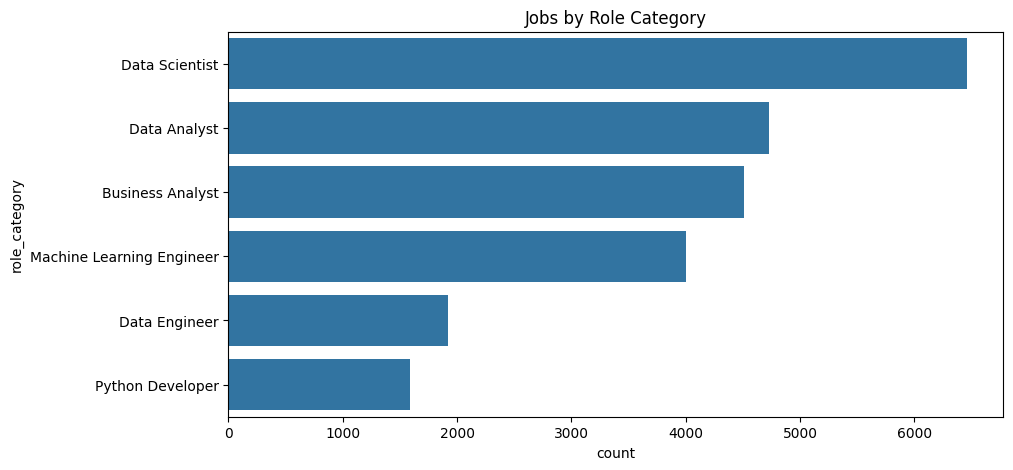

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(y="role_category",
              data=df,
              order=df.role_category.value_counts().index)

plt.title("Jobs by Role Category")
plt.show()

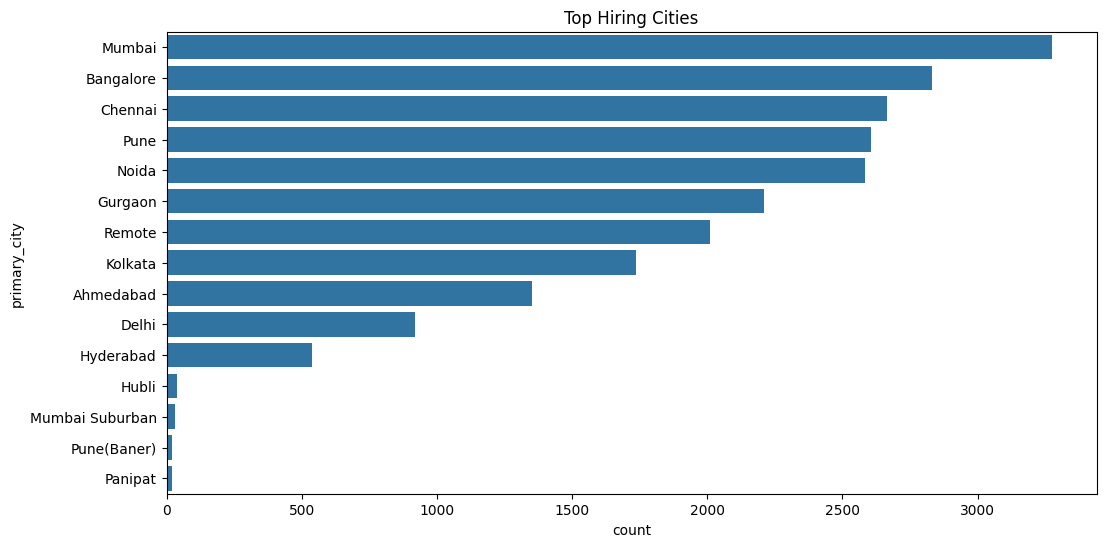

In [15]:
plt.figure(figsize=(12,6))
sns.countplot(y="primary_city",
              data=df,
              order=df.primary_city.value_counts().head(15).index)

plt.title("Top Hiring Cities")
plt.show()

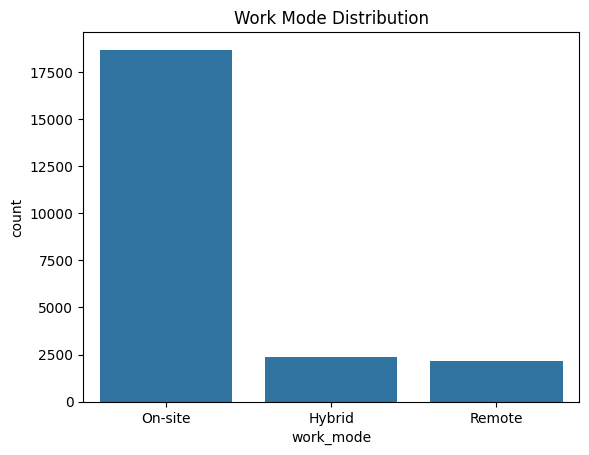

In [16]:
sns.countplot(x="work_mode", data=df)

plt.title("Work Mode Distribution")
plt.show()

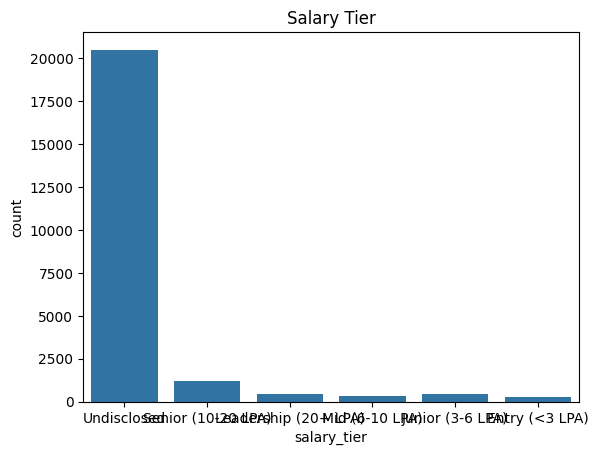

In [17]:
sns.countplot(x="salary_tier", data=df)

plt.title("Salary Tier")
plt.show()

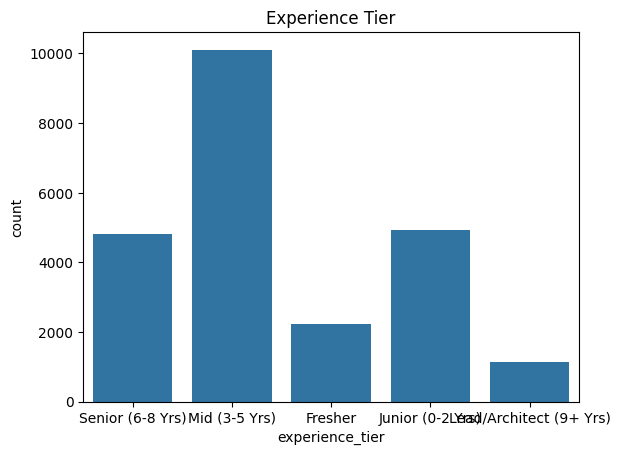

In [18]:
sns.countplot(x="experience_tier", data=df)

plt.title("Experience Tier")
plt.show()

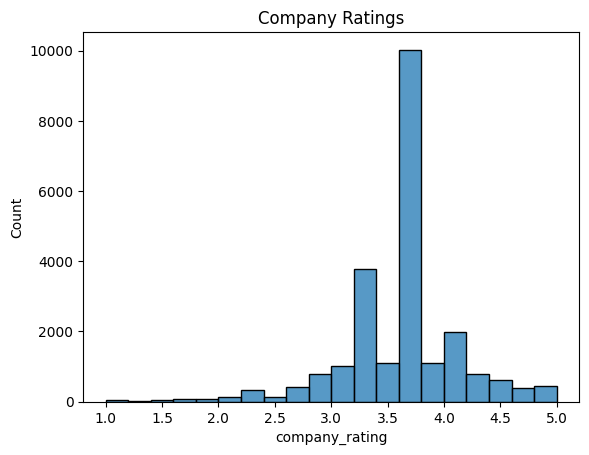

In [19]:
sns.histplot(df["company_rating"], bins=20)

plt.title("Company Ratings")
plt.show()

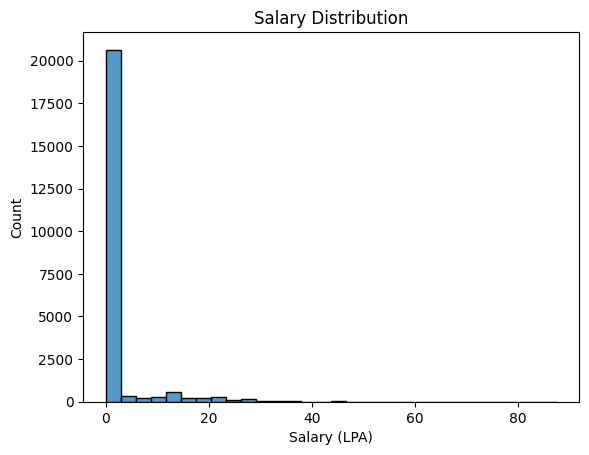

In [20]:
sns.histplot(df["salary_midpoint_lpa"], bins=30)

plt.title("Salary Distribution")
plt.xlabel("Salary (LPA)")
plt.show()

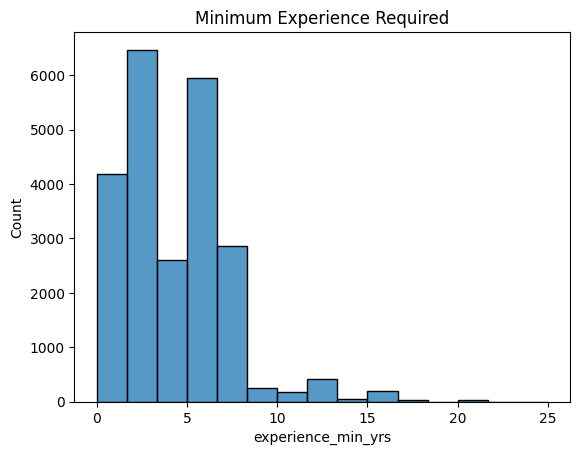

In [21]:
sns.histplot(df["experience_min_yrs"], bins=15)

plt.title("Minimum Experience Required")
plt.show()

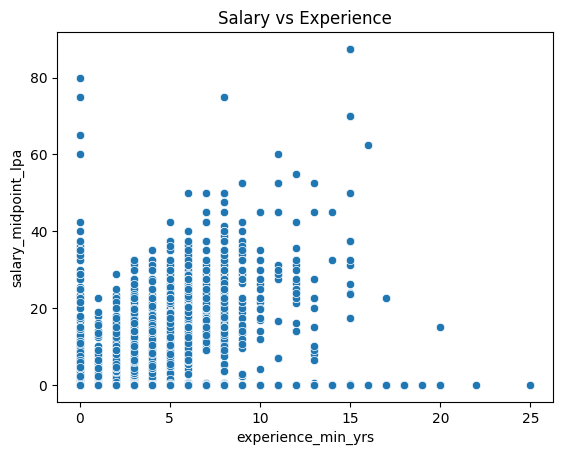

In [22]:
sns.scatterplot(
    x="experience_min_yrs",
    y="salary_midpoint_lpa",
    data=df
)

plt.title("Salary vs Experience")
plt.show()

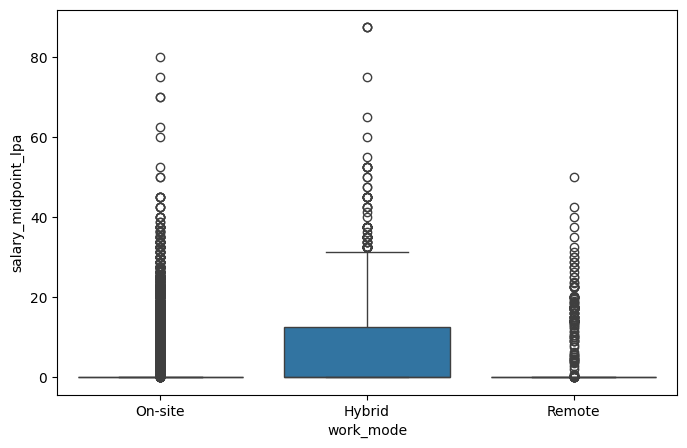

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="work_mode",
    y="salary_midpoint_lpa",
    data=df
)

plt.show()

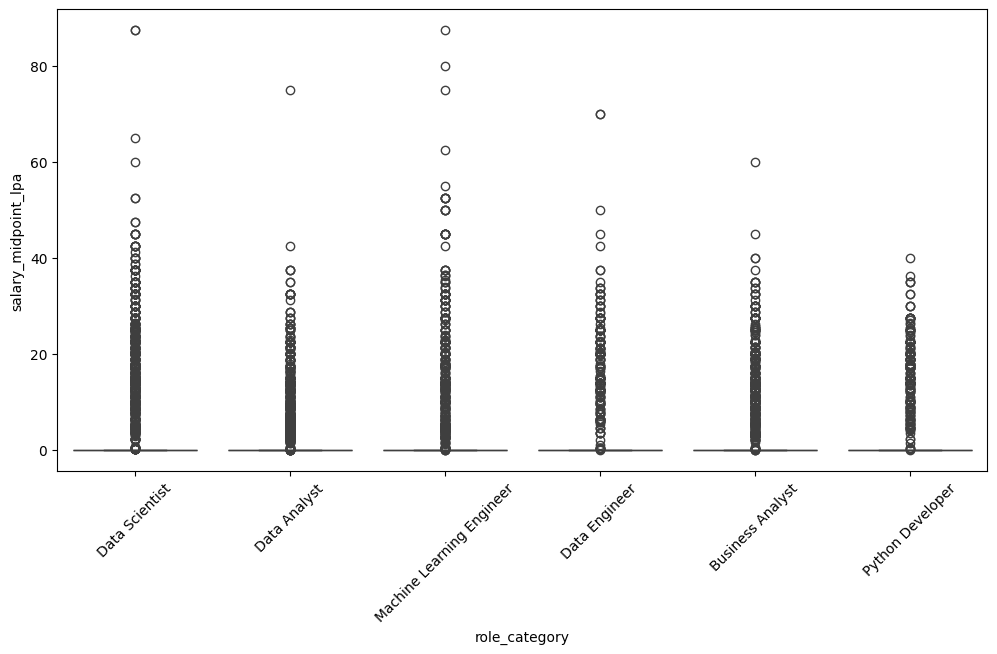

In [24]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="role_category",
    y="salary_midpoint_lpa",
    data=df
)

plt.xticks(rotation=45)
plt.show()

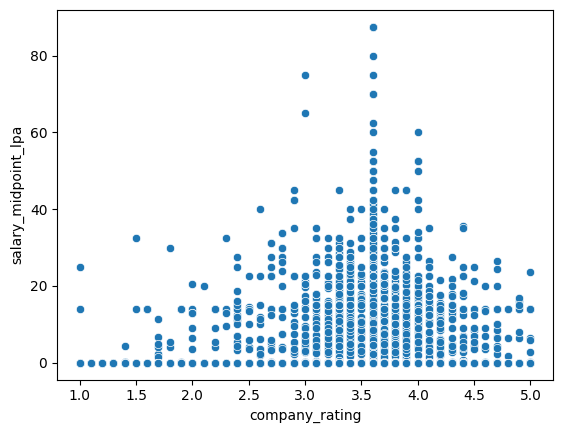

In [25]:
sns.scatterplot(
    x="company_rating",
    y="salary_midpoint_lpa",
    data=df
)

plt.show()

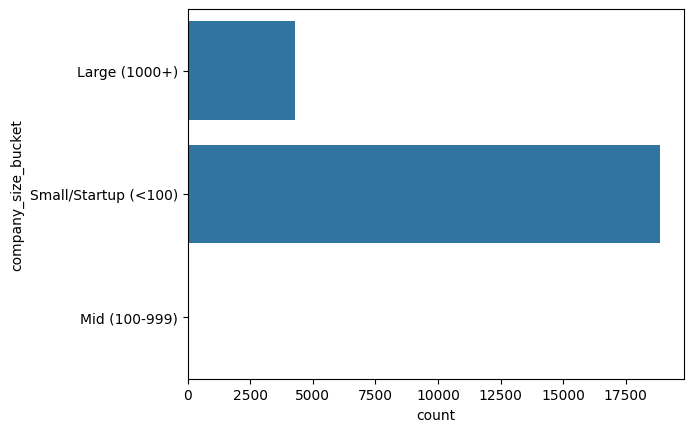

In [26]:
sns.countplot(
    y="company_size_bucket",
    data=df
)

plt.show()

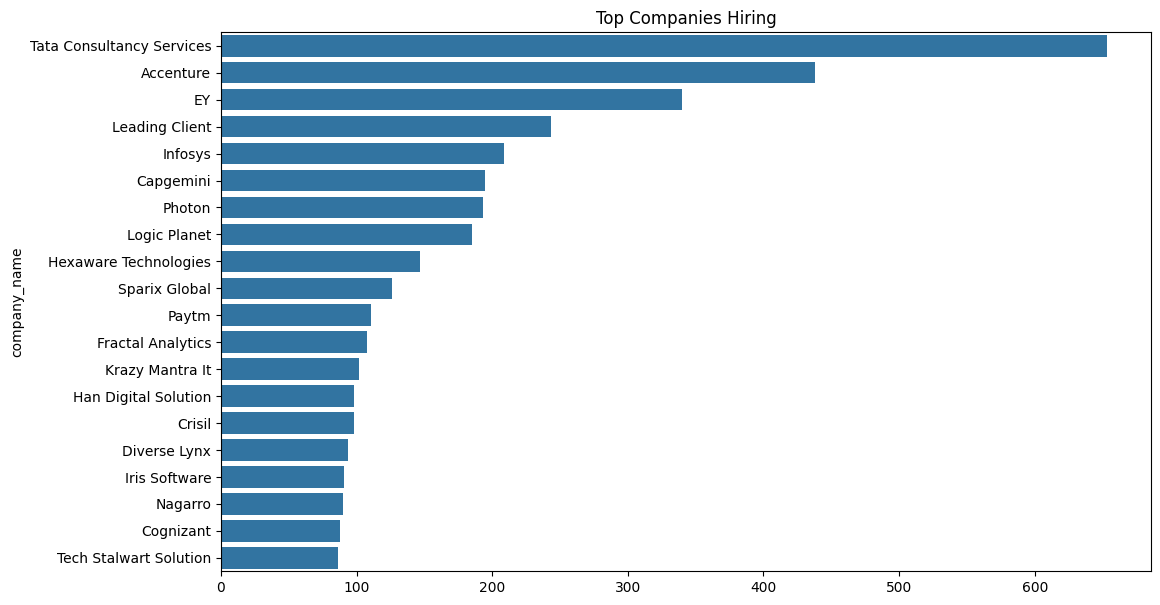

In [27]:
top = df.company_name.value_counts().head(20)

plt.figure(figsize=(12,7))

sns.barplot(
    x=top.values,
    y=top.index
)

plt.title("Top Companies Hiring")
plt.show()

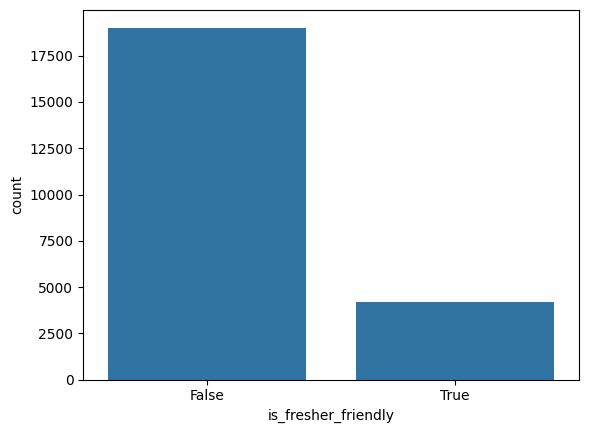

In [28]:
sns.countplot(
    x="is_fresher_friendly",
    data=df
)

plt.show()

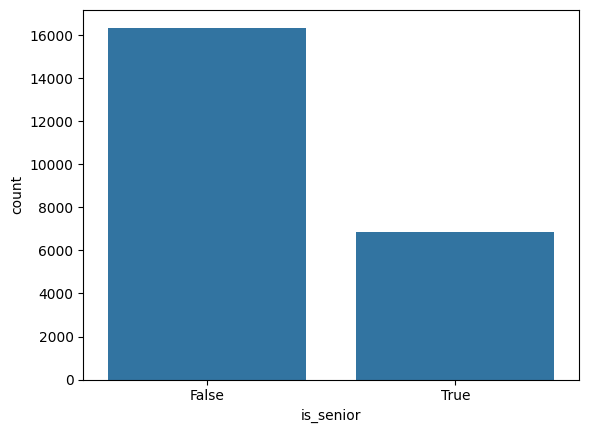

In [29]:
sns.countplot(
    x="is_senior",
    data=df
)

plt.show()

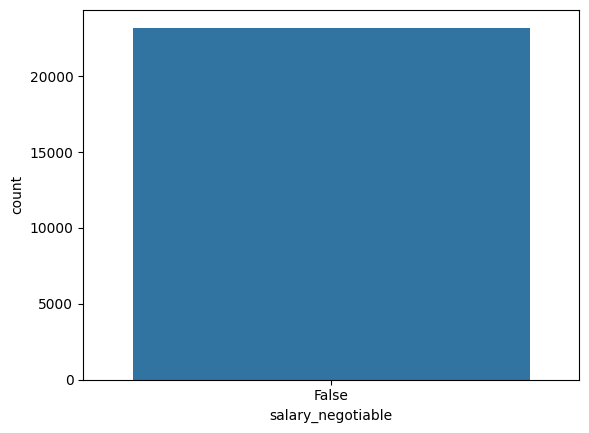

In [30]:
sns.countplot(
    x="salary_negotiable",
    data=df
)

plt.show()

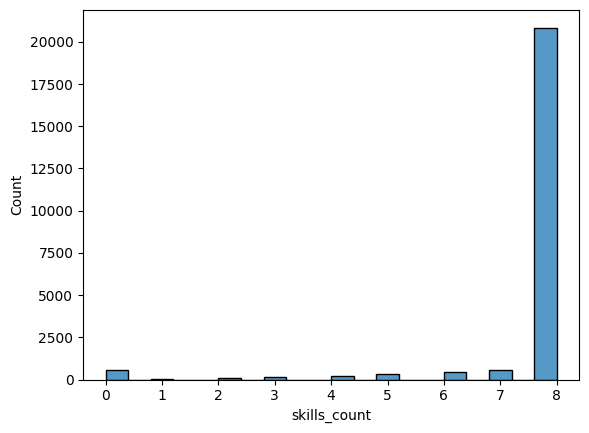

In [31]:
sns.histplot(
    df["skills_count"],
    bins=20
)

plt.show()

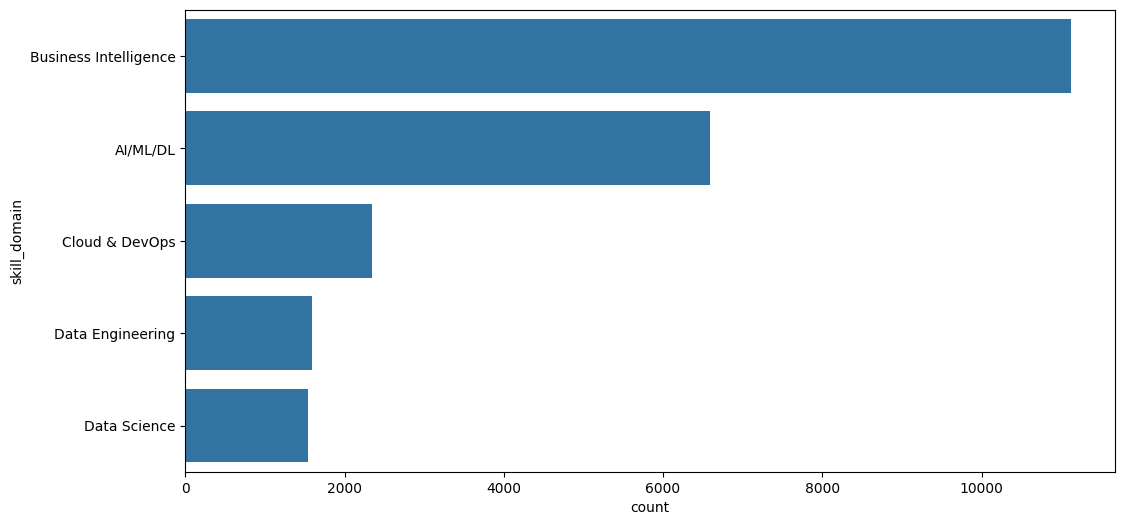

In [32]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="skill_domain",
    data=df,
    order=df.skill_domain.value_counts().index
)

plt.show()

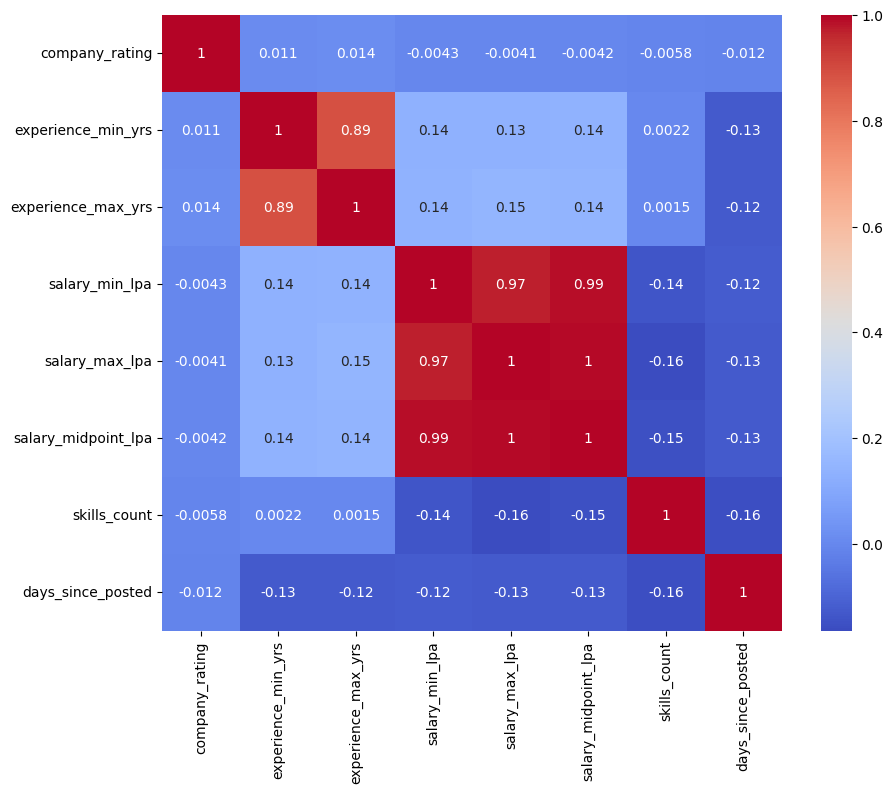

In [33]:
num_cols = [
    'company_rating',
    'experience_min_yrs',
    'experience_max_yrs',
    'salary_min_lpa',
    'salary_max_lpa',
    'salary_midpoint_lpa',
    'skills_count',
    'days_since_posted'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

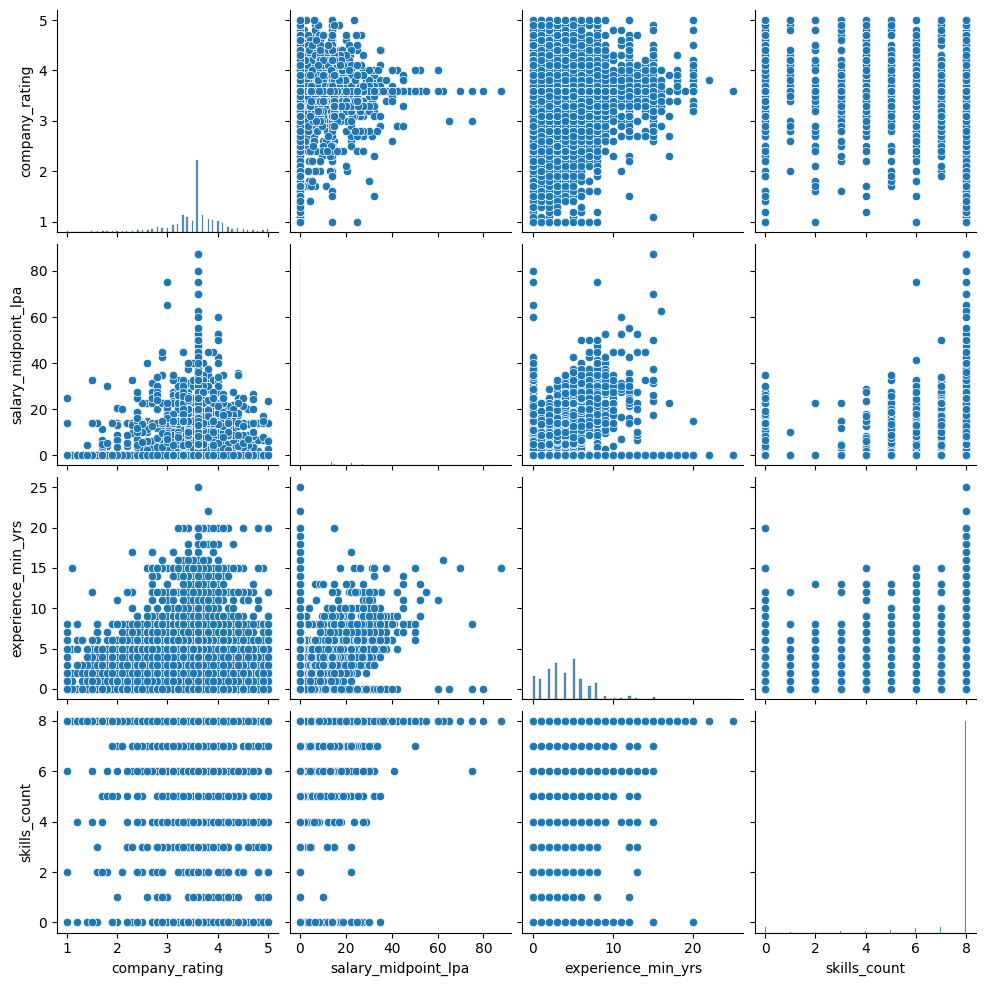

In [34]:
sns.pairplot(
    df[
        [
            'company_rating',
            'salary_midpoint_lpa',
            'experience_min_yrs',
            'skills_count'
        ]
    ]
)

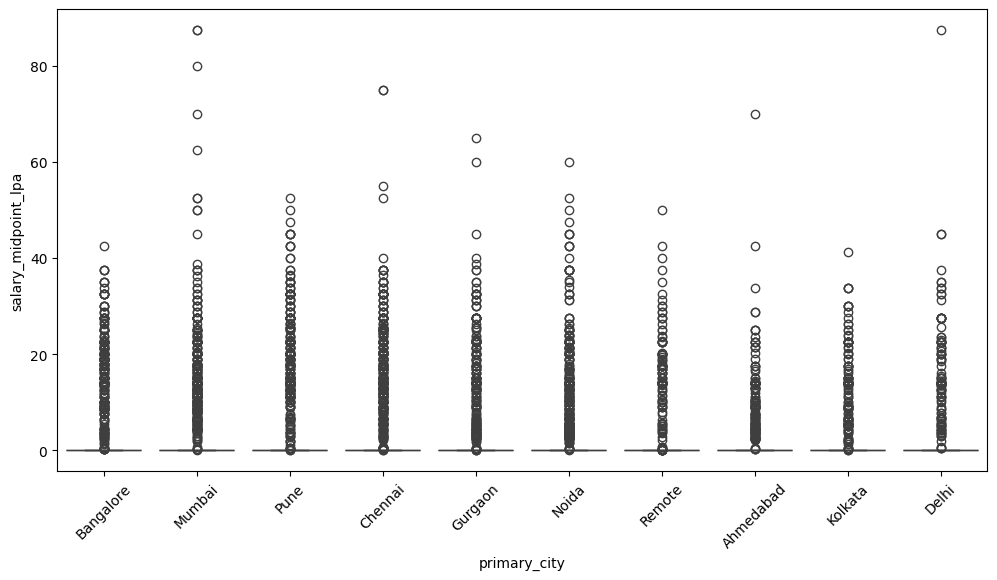

In [35]:
top_city = df.primary_city.value_counts().head(10).index

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[df.primary_city.isin(top_city)],
    x="primary_city",
    y="salary_midpoint_lpa"
)

plt.xticks(rotation=45)

plt.show()

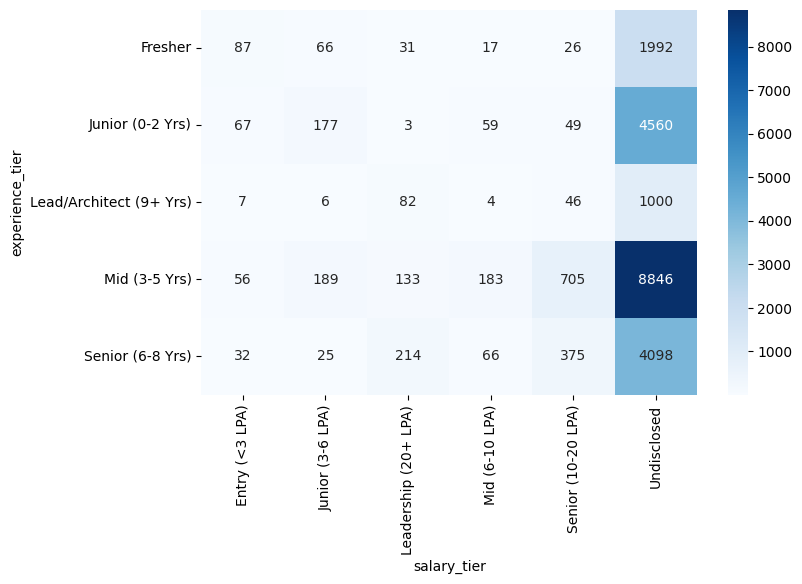

In [36]:
ct = pd.crosstab(df["experience_tier"], df["salary_tier"])

plt.figure(figsize=(8,5))
sns.heatmap(ct, annot=True, cmap="Blues", fmt="d")

plt.show()

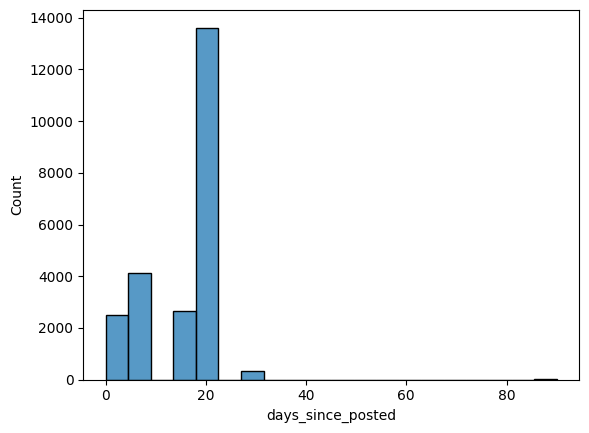

In [37]:
sns.histplot(
    df.days_since_posted,
    bins=20
)

plt.show()

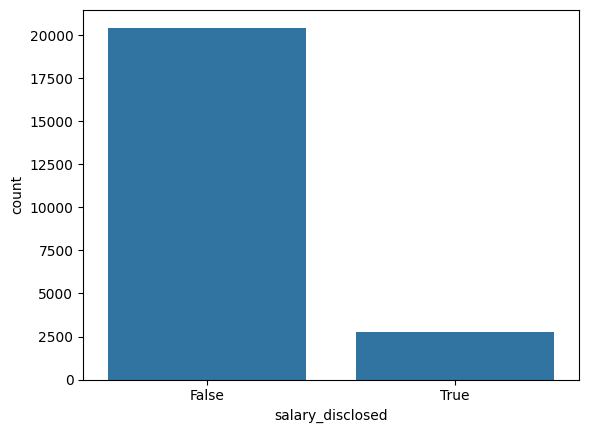

In [38]:
sns.countplot(
    x="salary_disclosed",
    data=df
)

plt.show()

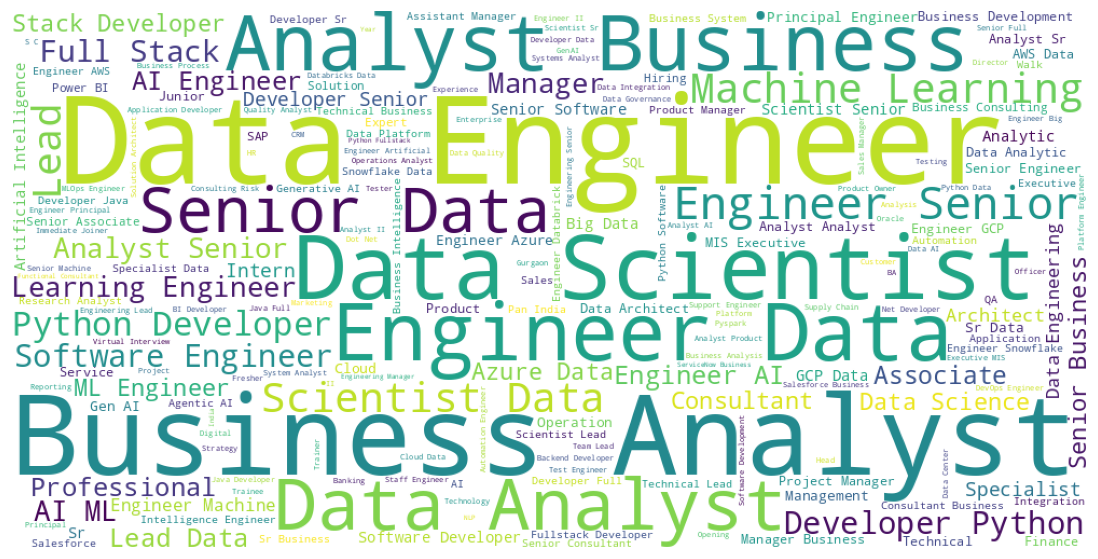

In [39]:
from wordcloud import WordCloud

text = " ".join(df.job_title.astype(str))

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wc)
plt.axis("off")
plt.show()

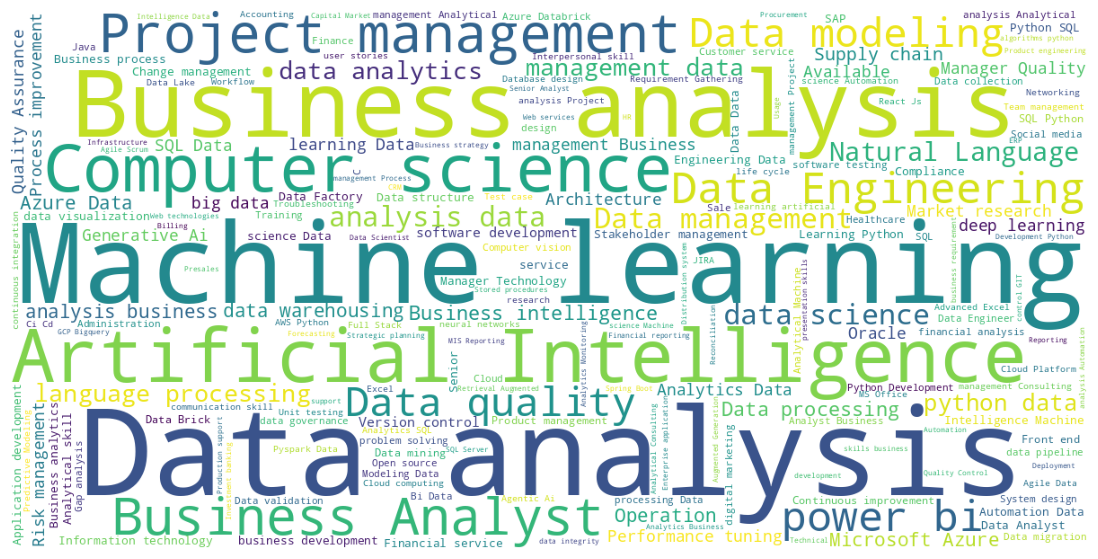

In [40]:
text = " ".join(df.skills_required.fillna(""))

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wc)
plt.axis("off")
plt.show()

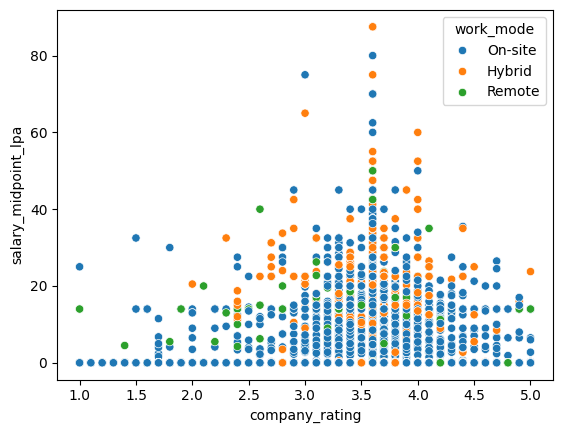

In [41]:
sns.scatterplot(
    x="company_rating",
    y="salary_midpoint_lpa",
    hue="work_mode",
    data=df
)

plt.show()

## Feature engineering

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [43]:
target = "salary_tier"

In [44]:
leakage_columns = [

    "salary_raw",
    "salary_min_lpa",
    "salary_max_lpa",
    "salary_midpoint_lpa",

]

In [45]:
drop_columns = leakage_columns + [

    "job_id",
    "job_url",
    "scraped_at"

]

In [46]:
df = df.drop(columns=drop_columns)

In [47]:
X = df.drop(columns=[target])

y = df[target]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

In [49]:
cat_cols = X_train.select_dtypes(include="object").columns

num_cols = X_train.select_dtypes(exclude="object").columns

In [50]:
num_imputer = SimpleImputer(strategy="median")

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])

X_test[num_cols] = num_imputer.transform(X_test[num_cols])

In [51]:
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])

X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

In [52]:
encoder = OrdinalEncoder(

    handle_unknown="use_encoded_value",
    unknown_value=-1

)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])

X_test[cat_cols] = encoder.transform(X_test[cat_cols])

In [53]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)

y_test = target_encoder.transform(y_test)

In [54]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=500),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(random_state=42),

    "Naive Bayes":
        GaussianNB(),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(probability=True)

}

Logistic Regression

Accuracy : 0.8752424046541694
Precision : 0.7857973609786765
Recall : 0.8752424046541694
F1 Score : 0.8266357543175091
ROC AUC : 0.6496004686432871

Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        50
           1       0.00      0.00      0.00        93
           2       0.00      0.00      0.00        92
           3       0.00      0.00      0.00        66
           4       0.07      0.01      0.01       240
           5       0.89      0.99      0.93      4100

    accuracy                           0.88      4641
   macro avg       0.16      0.17      0.16      4641
weighted avg       0.79      0.88      0.83      4641



<Figure size 1000x800 with 0 Axes>

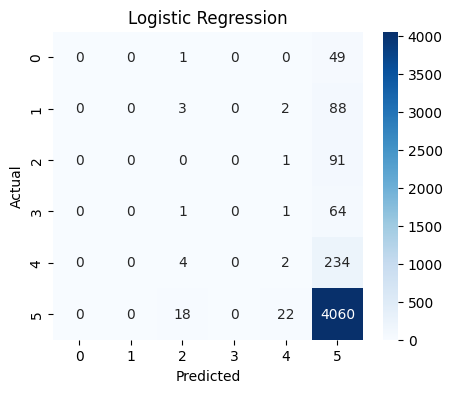

Decision Tree

Accuracy : 0.9301874595992243
Precision : 0.9334696317408908
Recall : 0.9301874595992243
F1 Score : 0.9305085172312716
ROC AUC : 0.7439796081847664

Classification Report
              precision    recall  f1-score   support

           0       0.29      0.44      0.35        50
           1       0.30      0.27      0.28        93
           2       0.40      0.60      0.48        92
           3       0.26      0.27      0.26        66
           4       0.62      0.44      0.51       240
           5       1.00      1.00      1.00      4100

    accuracy                           0.93      4641
   macro avg       0.48      0.50      0.48      4641
weighted avg       0.93      0.93      0.93      4641



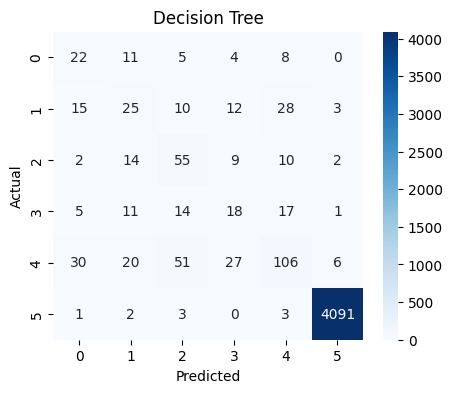

Random Forest

Accuracy : 0.949364361129067
Precision : 0.9458366174012814
Recall : 0.949364361129067
F1 Score : 0.945871757455697
ROC AUC : 0.979427289778394

Classification Report
              precision    recall  f1-score   support

           0       0.41      0.40      0.40        50
           1       0.51      0.42      0.46        93
           2       0.65      0.58      0.61        92
           3       0.24      0.06      0.10        66
           4       0.61      0.83      0.70       240
           5       1.00      1.00      1.00      4100

    accuracy                           0.95      4641
   macro avg       0.57      0.55      0.55      4641
weighted avg       0.95      0.95      0.95      4641



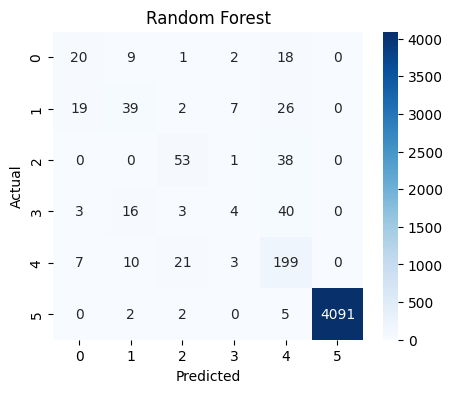

Gradient Boosting

Accuracy : 0.9321266968325792
Precision : 0.9315039682852583
Recall : 0.9321266968325792
F1 Score : 0.928879997859253
ROC AUC : 0.980652539437663

Classification Report
              precision    recall  f1-score   support

           0       0.25      0.48      0.33        50
           1       0.47      0.29      0.36        93
           2       0.42      0.67      0.52        92
           3       0.31      0.12      0.17        66
           4       0.69      0.48      0.57       240
           5       0.99      1.00      0.99      4100

    accuracy                           0.93      4641
   macro avg       0.52      0.51      0.49      4641
weighted avg       0.93      0.93      0.93      4641



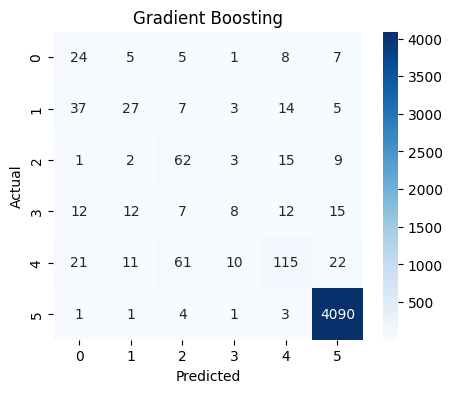

Extra Trees

Accuracy : 0.949364361129067
Precision : 0.9484443529892636
Recall : 0.949364361129067
F1 Score : 0.945980215209405
ROC AUC : 0.9736930155623096

Classification Report
              precision    recall  f1-score   support

           0       0.46      0.34      0.39        50
           1       0.50      0.60      0.55        93
           2       0.63      0.47      0.54        92
           3       0.46      0.09      0.15        66
           4       0.61      0.80      0.69       240
           5       1.00      1.00      1.00      4100

    accuracy                           0.95      4641
   macro avg       0.61      0.55      0.55      4641
weighted avg       0.95      0.95      0.95      4641



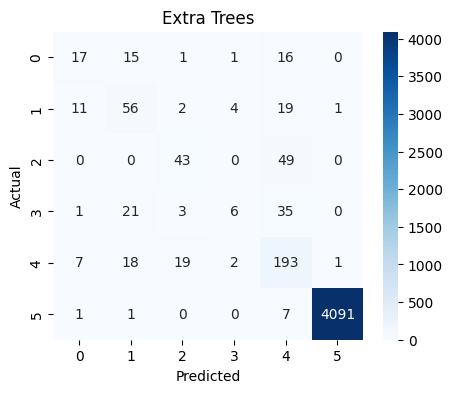

Naive Bayes

Accuracy : 0.9319112260288731
Precision : 0.9402482329563783
Recall : 0.9319112260288731
F1 Score : 0.9333004481810234
ROC AUC : 0.9730658420444528

Classification Report
              precision    recall  f1-score   support

           0       0.40      0.16      0.23        50
           1       0.43      0.46      0.45        93
           2       0.37      0.61      0.46        92
           3       0.22      0.42      0.29        66
           4       0.64      0.42      0.51       240
           5       1.00      1.00      1.00      4100

    accuracy                           0.93      4641
   macro avg       0.51      0.51      0.49      4641
weighted avg       0.94      0.93      0.93      4641



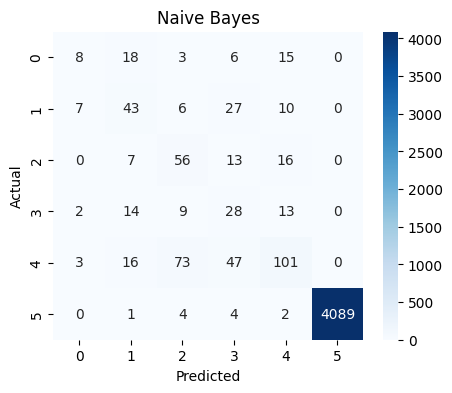

KNN

Accuracy : 0.8683473389355743
Precision : 0.8251450388426884
Recall : 0.8683473389355743
F1 Score : 0.8400951621887268
ROC AUC : 0.5894710223281847

Classification Report
              precision    recall  f1-score   support

           0       0.17      0.02      0.04        50
           1       0.00      0.00      0.00        93
           2       0.14      0.07      0.09        92
           3       0.00      0.00      0.00        66
           4       0.56      0.20      0.30       240
           5       0.90      0.97      0.93      4100

    accuracy                           0.87      4641
   macro avg       0.29      0.21      0.23      4641
weighted avg       0.83      0.87      0.84      4641



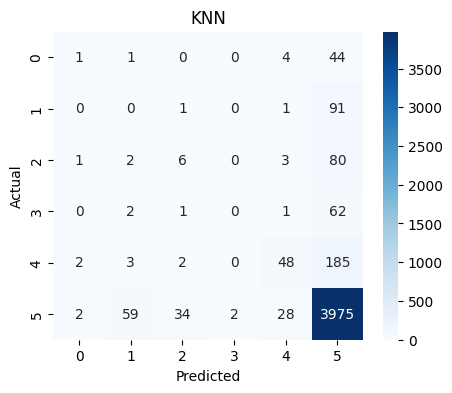

SVM

Accuracy : 0.883430295195001
Precision : 0.7804490864683268
Recall : 0.883430295195001
F1 Score : 0.8287528224000695
ROC AUC : 0.5635670390739801

Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        50
           1       0.00      0.00      0.00        93
           2       0.00      0.00      0.00        92
           3       0.00      0.00      0.00        66
           4       0.00      0.00      0.00       240
           5       0.88      1.00      0.94      4100

    accuracy                           0.88      4641
   macro avg       0.15      0.17      0.16      4641
weighted avg       0.78      0.88      0.83      4641



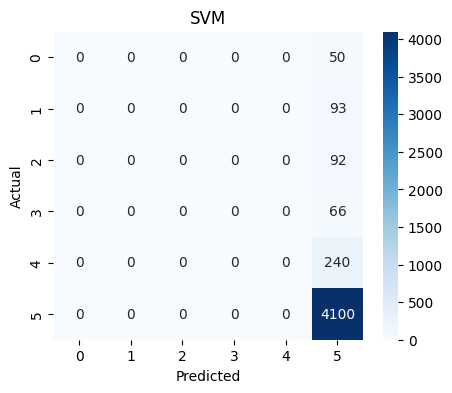

In [55]:
results = []

plt.figure(figsize=(10,8))

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    # ROC-AUC

    if len(np.unique(y)) == 2:

        y_prob = model.predict_proba(X_test)[:,1]

        roc = roc_auc_score(y_test, y_prob)

        fpr, tpr, _ = roc_curve(y_test, y_prob)

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f"{name} (AUC={roc:.3f})"
        )

    else:

        y_prob = model.predict_proba(X_test)

        roc = roc_auc_score(
            y_test,
            y_prob,
            multi_class="ovr"
        )

    results.append([

        name,
        accuracy,
        precision,
        recall,
        f1,
        roc

    ])

    print("="*70)

    print(name)

    print("="*70)

    print()

    print("Accuracy :",accuracy)

    print("Precision :",precision)

    print("Recall :",recall)

    print("F1 Score :",f1)

    print("ROC AUC :",roc)

    print()

    print("Classification Report")

    print(classification_report(y_test,y_pred))

    cm = confusion_matrix(y_test,y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(name)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

In [56]:
if len(np.unique(y)) == 2:

    plt.plot(
        [0,1],
        [0,1],
        linestyle="--",
        color="black"
    )

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.show()

In [57]:
results = pd.DataFrame(

    results,

    columns=[

        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"

    ]

)

In [58]:
results = results.sort_values(

    by="Accuracy",

    ascending=False

)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.949364,0.945837,0.949364,0.945872,0.979427
4,Extra Trees,0.949364,0.948444,0.949364,0.945980,0.973693
3,Gradient Boosting,0.932127,0.931504,0.932127,0.928880,0.980653
5,Naive Bayes,0.931911,0.940248,0.931911,0.933300,0.973066
1,Decision Tree,0.930187,0.933470,0.930187,0.930509,0.743980
7,SVM,0.883430,0.780449,0.883430,0.828753,0.563567
0,Logistic Regression,0.875242,0.785797,0.875242,0.826636,0.649600
6,KNN,0.868347,0.825145,0.868347,0.840095,0.589471


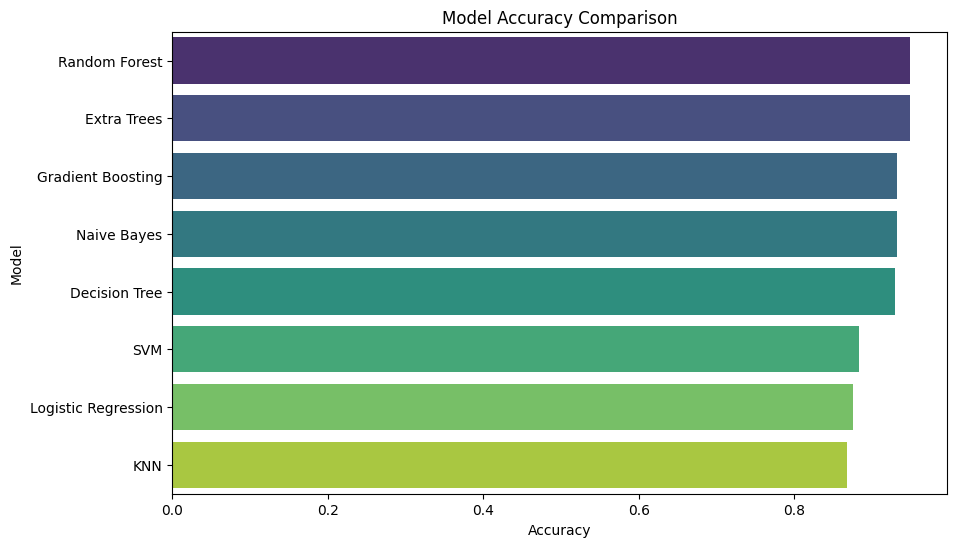

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=results,

    x="Accuracy",

    y="Model",

    palette="viridis"

)

plt.title("Model Accuracy Comparison")

plt.show()

In [60]:
best_model = results.iloc[0]

print(best_model)

Model        Random Forest
Accuracy          0.949364
Precision         0.945837
Recall            0.949364
F1 Score          0.945872
ROC AUC           0.979427
Name: 2, dtype: object


In [61]:
roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr"
)

np.float64(0.5635670390739801)

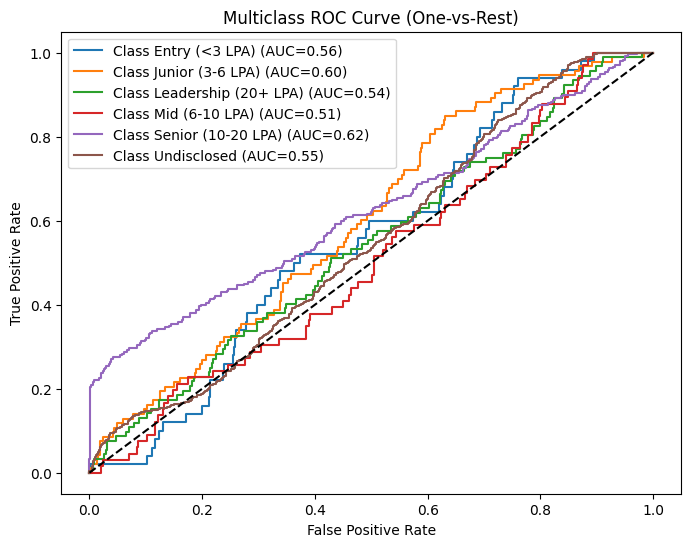

In [62]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {target_encoder.inverse_transform([i])[0]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

## Thank you...pls upvote!!!!!!!!!!!!!!